<a href="https://colab.research.google.com/github/asmitaagarwal756/Earthquake-Prediction/blob/main/Decision_tree_and_Regression_tree_EARTHQUAKE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("earthquakes.csv")
df.head()


,id,impact.gap,impact.magnitude,impact.significance,location.depth,location.distance,location.full,location.latitude,location.longitude,location.name,time.day,time.epoch,time.full,time.hour,time.minute,time.month,time.second,time.year
0,nc72666881,122.00,1.43,31,15.12,0.10340,"13km E of Livermore, California",37.672333,-121.619000,California,27,1469593183550,2016-07-27 00:19:43,0,19,7,43,2016
1,us20006i0y,30.00,4.90,371,97.07,1.43900,"58km WNW of Pakokku, Burma",21.514600,94.572100,Burma,27,1469593228220,2016-07-27 00:20:28,0,20,7,28,2016
2,nc72666891,249.00,0.06,0,4.39,0.02743,"12km SE of Mammoth Lakes, California",37.576500,-118.859167,California,27,1469593897150,2016-07-27 00:31:37,0,31,7,37,2016
3,nc72666896,122.00,0.40,2,1.09,0.02699,"6km SSW of Mammoth Lakes, California",37.595833,-118.994833,California,27,1469594144150,2016-07-27 00:35:44,0,35,7,44,2016
4,nn00553447,113.61,0.30,1,7.60,0.06300,"16km SSE of Mogul, Nevada",39.377500,-119.845000,Nevada,27,1469594519667,2016-07-27 00:41:59,0,41,7,59,2016


In [ ]:
# Create severity class based on magnitude
def magnitude_class(mag):
    if mag < 4.0:
        return 0   # Low
    elif mag < 6.0:
        return 1   # Moderate
    else:
        return 2   # High

df['severity'] = df['impact.magnitude'].apply(magnitude_class)


In [ ]:
features = [
    'impact.gap',
    'location.depth',
    'location.latitude',
    'location.longitude',
    'impact.significance',
    'time.hour',
    'time.month'
]

X = df[features]
y = df['severity']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
def entropy(y):
    values, counts = np.unique(y, return_counts=True)
    probabilities = counts / counts.sum()
    return -np.sum(probabilities * np.log2(probabilities))


In [ ]:
dataset_entropy = entropy(y_train)
print("Entropy of training dataset:", dataset_entropy)


Entropy of training dataset: 0.4050733211415098


In [ ]:
def information_gain(X, y, feature):
    total_entropy = entropy(y)

    values, counts = np.unique(X[feature], return_counts=True)
    weighted_entropy = 0

    for value, count in zip(values, counts):
        subset_y = y[X[feature] == value]
        weighted_entropy += (count / len(X)) * entropy(subset_y)

    return total_entropy - weighted_entropy


In [ ]:
gain_depth = information_gain(X_train, y_train, 'location.depth')
print("Information Gain (location.depth):", gain_depth)


Information Gain (location.depth): 0.3373483997749411


In [ ]:
dt = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,          # Keep tree readable
    random_state=42
)

dt.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

In [ ]:
y_pred = dt.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", accuracy)


Decision Tree Accuracy: 0.9988088147706968


In [ ]:
print(confusion_matrix(y_test, y_pred))


[[1548    1    0]
 [   0  129    1]
 [   0    0    0]]


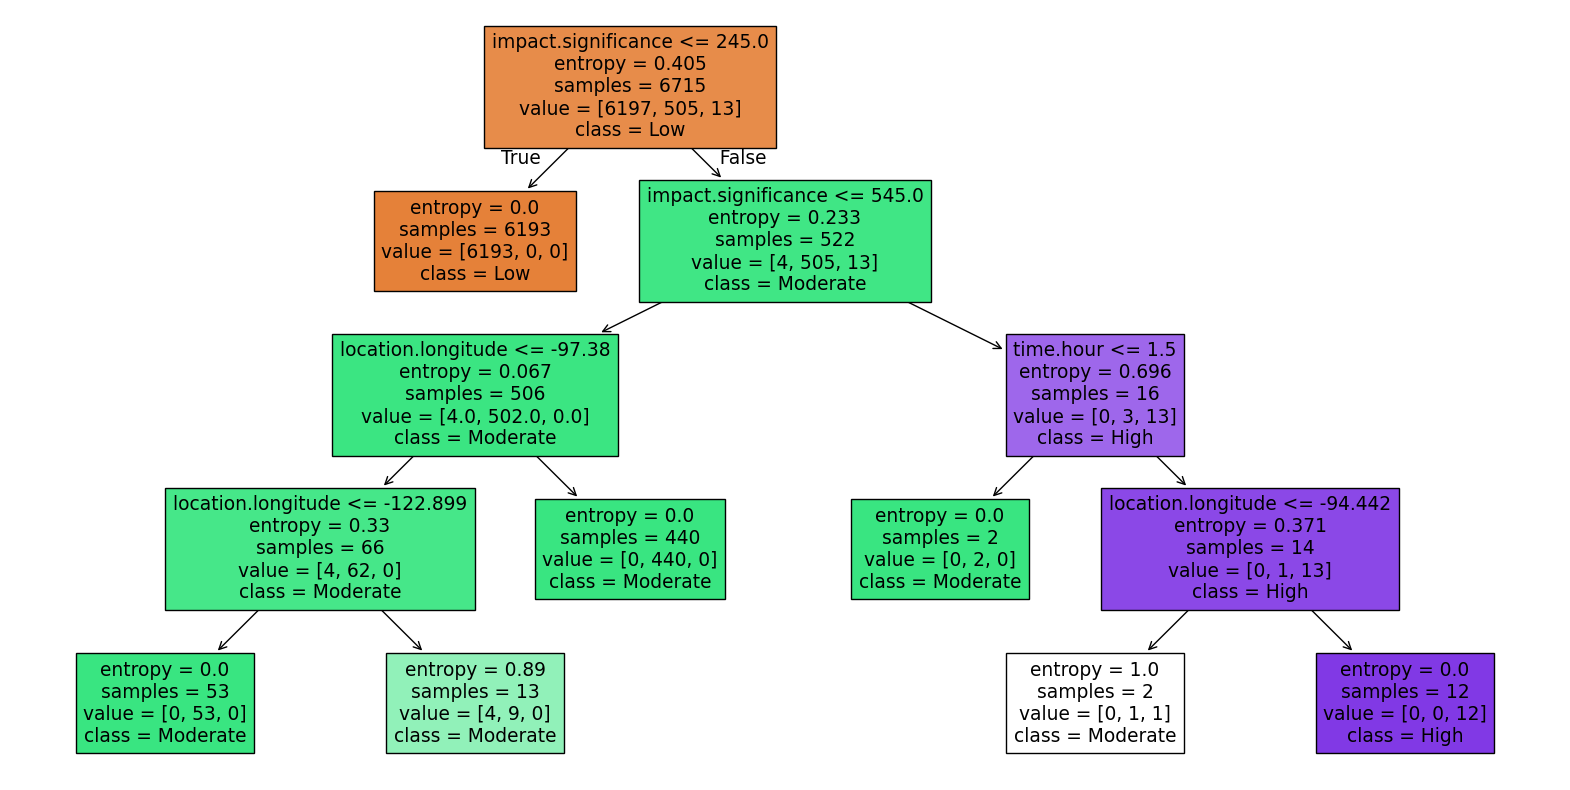

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(
    dt,
    feature_names=features,
    class_names=['Low', 'Moderate', 'High'],
    filled=True
)
plt.show()


In [ ]:
# Regression target
y_reg = df['impact.significance']

# Regression features
X_reg = df[
    [
        'impact.magnitude',
        'impact.gap',
        'location.depth',
        'location.latitude',
        'location.longitude',
        'time.hour',
        'time.month'
    ]
]


In [ ]:
from sklearn.model_selection import train_test_split

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt_reg = DecisionTreeRegressor(
    criterion='squared_error',   # Regression uses variance reduction
    max_depth=5,
    random_state=42
)

dt_reg.fit(Xr_train, yr_train)


DecisionTreeRegressor(max_depth=5, random_state=42)

In [ ]:
yr_pred = dt_reg.predict(Xr_test)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(yr_test, yr_pred)
mse = mean_squared_error(yr_test, yr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(yr_test, yr_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score(Accuracy):", r2)


Mean Absolute Error (MAE): 3.3081104560629395
Mean Squared Error (MSE): 119.83268717177229
Root Mean Squared Error (RMSE): 10.946811735467652
R² Score(Accuracy): 0.9857545795982612


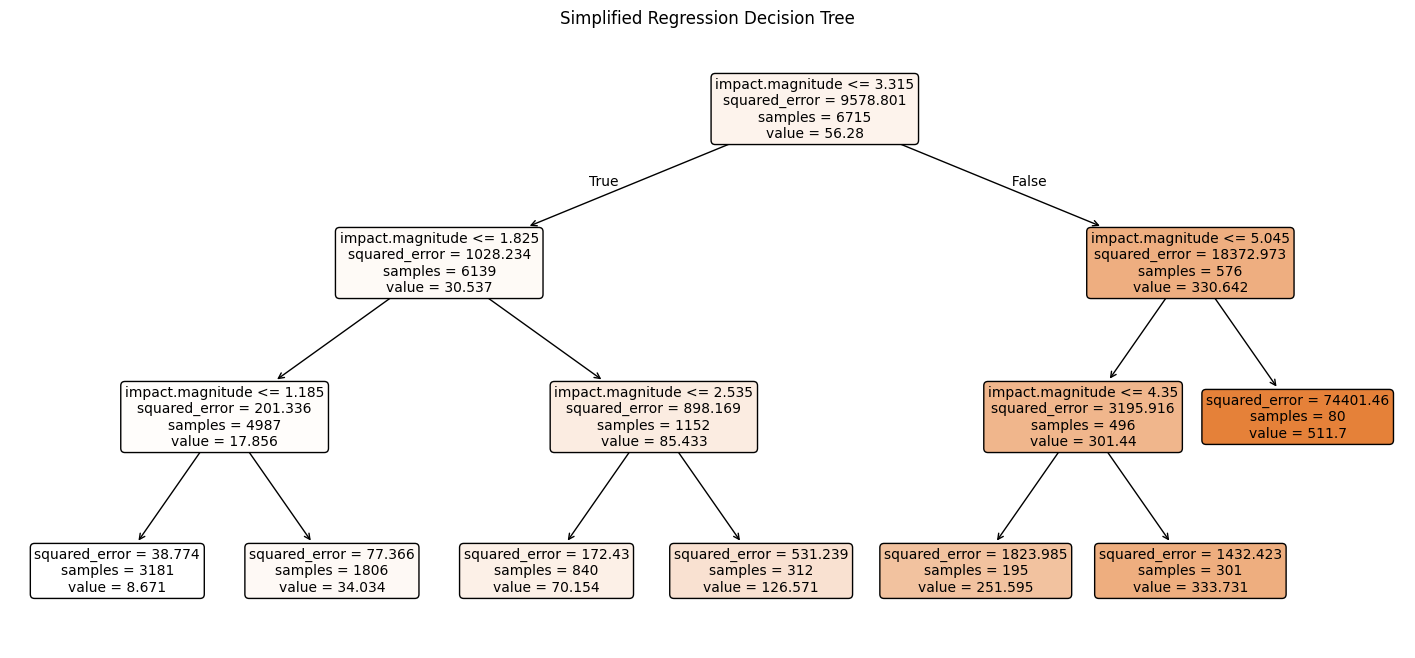

In [ ]:
dt_reg = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=3,          # 👈 keeps tree readable
    min_samples_split=100,
    min_samples_leaf=50,
    random_state=42
)

dt_reg.fit(Xr_train, yr_train)
plt.figure(figsize=(18,8))

plot_tree(
    dt_reg,
    feature_names=X_reg.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Simplified Regression Decision Tree")
plt.show()


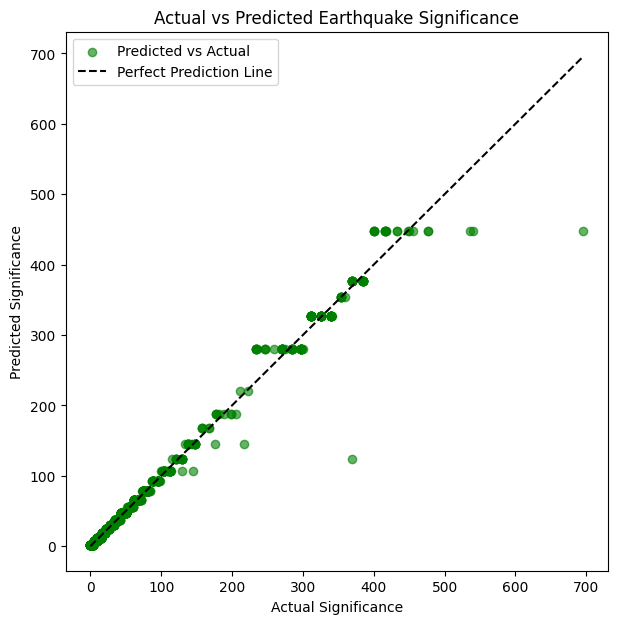

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(yr_test, yr_pred, color='green', alpha=0.6, label="Predicted vs Actual")
plt.plot(
    [yr_test.min(), yr_test.max()],
    [yr_test.min(), yr_test.max()],
    color='black',
    linestyle='--',
    label="Perfect Prediction Line"
)

plt.xlabel("Actual Significance")
plt.ylabel("Predicted Significance")
plt.title("Actual vs Predicted Earthquake Significance")
plt.legend()
plt.show()
